In [ ]:
# PRADA against benchmarker icSHAPE --- --- 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn import metrics   
import re 

In [ ]:
## 1. Extend Figure 6g --- --- 

In [ ]:
## 1. benchmarker icshape auroc --- 

In [2]:
### COX1 --- --- --- --- --- --- --- ---

def get_icShape_single(sample):
    
    dir = './Data/'
    infile = dir+'GSE74353_HS_293T_icSHAPE_BaseReactivities.txt'
    shapefile = open(infile)
    outtmp = open(dir+'icshape_'+ 'MT-CO1' +'.txt', 'w') 

    for line in shapefile:
        if re.match("^ENST00000361624", line): 
            l = line.strip()
            outtmp.write(l)

    shapefile.close()
    outtmp.close()


def get_single_transcript_shape(gene):

    dir = './Data/'
    mitoall = pd.read_csv(dir+'mitoall_transcripts_ids.txt',sep='\t')
    mitoall.columns
    mitoall.columns = ['tid', 'g_id', 'g_name', 'g_biotype', 't_name', 't_biotype']
    print(mitoall.g_name.unique())
    flt = mitoall[mitoall['g_name'] == gene]
    tid=list(flt.tid)[0]
    print(tid) 

    get_icShape_single('GSE74353_HS_293T_icSHAPE_BaseReactivities.txt')

    dir = './Data/'
    pub = pd.read_csv(dir+'icshape_'+gene+'.txt',header=None,sep='\t')
    pub = pub.T
    pub.columns = ['shape_reactivity']

    reac = pub.iloc[3:]
    reac['tid'] = list(pub.shape_reactivity)[0]
    reac['length'] = list(pub.shape_reactivity)[1]
    reac['coverage'] = list(pub.shape_reactivity)[2]
    reac['Nucleotide'] = list(range(1,list(pub.shape_reactivity)[1]+1))
    reac['Nucleotide'] = reac['Nucleotide']+4

    reac.to_csv(dir+'icshape_'+gene+'_shape.txt',sep='\t')

    return reac

['MTFR1L' 'MT1HL1' 'MTF2' 'MTR' 'MTX1' 'MTMR11' 'MTHFR' 'MTARC2' 'MTARC1'
 'MTOR' 'MTF1' 'MTX2' 'MTIF2' 'MTA3' 'MTHFD2' 'MTLN' 'MTERF4' 'MTMR14'
 'MTTP' 'MTHFD2L' 'MTNR1A' 'MTRR' 'MTREX' 'MTMR12' 'MTX3' 'MTRES1' 'MTFR2'
 'MTRF1L' 'MTHFD1L' 'MTO1' 'MTCH1' 'MTERF1' 'MTPN' 'MTURN' 'MTMR8' 'MTCP1'
 'MTM1' 'MTMR1' 'MTDH' 'MTBP' 'MTERF3' 'MTFR1' 'MTSS1' 'MTMR9' 'MTUS1'
 'MTMR7' 'MTAP' 'MTMR2' 'MTNR1B' 'MTA2' 'MTCH2' 'MTG1' 'MTPAP' 'MTRFR'
 'MTERF2' 'MTRF1' 'MTIF3' 'MTUS2' 'MTMR6' 'MTA1' 'MTHFD1' 'MTHFS' 'MTFMT'
 'MTMR10' 'MTHFSD' 'MT4' 'MT2A' 'MT1E' 'MT1M' 'MT1A' 'MT1B' 'MT1F' 'MT1X'
 'MT1H' 'MT3' 'MT1G' 'MTSS2' 'MTMR4' 'MTCL1' 'MTG2' 'MTMR3' 'MTFP1'
 'MT-TF' 'MT-RNR1' 'MT-TV' 'MT-RNR2' 'MT-TL1' 'MT-ND1' 'MT-TI' 'MT-TQ'
 'MT-TM' 'MT-ND2' 'MT-TW' 'MT-TA' 'MT-TN' 'MT-TC' 'MT-TY' 'MT-CO1'
 'MT-TS1' 'MT-TD' 'MT-CO2' 'MT-TK' 'MT-ATP8' 'MT-ATP6' 'MT-CO3' 'MT-TG'
 'MT-ND3' 'MT-TR' 'MT-ND4L' 'MT-ND4' 'MT-TH' 'MT-TS2' 'MT-TL2' 'MT-ND5'
 'MT-ND6' 'MT-TE' 'MT-CYB' 'MT-TT' 'MT-TP']
ENST00000361624
(1608

/tmp/ipykernel_11558/1548487865.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reac['tid'] = list(pub.shape_reactivity)[0]
/tmp/ipykernel_11558/1548487865.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reac['length'] = list(pub.shape_reactivity)[1]
/tmp/ipykernel_11558/1548487865.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

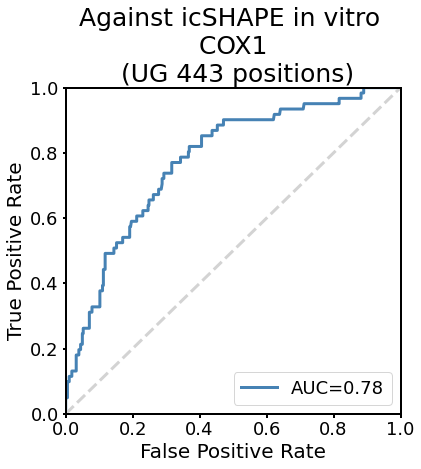

In [3]:
### A. get the bench files --- --- 

reac = get_single_transcript_shape('MT-CO1')
flt = reac.dropna() 
cutoff1=0.8
cutoff2=0.2
tmp1 = flt[flt['shape_reactivity']>=cutoff1]
tmp1['strand'] = 1
tmp2 = flt[flt['shape_reactivity']<=cutoff2]
tmp2['strand'] = 0
bench=pd.concat([tmp1,tmp2]) 

### B. combine the PRADA with bench icSHAPE  --- 

dir = "./Data/"
vitro = pd.read_csv(dir+'vitro_heavy_NC_012920.1_profile.txt',sep='\t')
vitro = vitro[(vitro['Modified_effective_depth'] >=5000) & (vitro['Untreated_effective_depth'] >=5000)]
cox1= vitro[(vitro['Nucleotide']>=5900) & (vitro['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899

seq=list(cox1.Sequence)
sequence=''.join(map(str,seq))
print(sequence)


df = pd.merge(bench,cox1, how='inner',on=['Nucleotide','Nucleotide'])
flt=df[(df['Sequence']=='T') | (df['Sequence']=='G') | (df['Sequence']=='U')]

flt.to_csv('./Data/'+'source_data_Efig6g.csv',sep=',')

### C. plot the AUROC  --- 

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)
    
fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title("Against icSHAPE in vitro \n COX1 \n (UG "+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig6g_PRADA_COX1_AUROC_against_icSHAPE.pdf',bbox_inches='tight', dpi=300)